In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jpharishkumar/her-predictor-dataset/135 HER_Dataset_Batch1_Batch2_with_engineered_features.xlsx


In [7]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Locate the dataset automatically inside Kaggle paths (FIXED TYPO HERE)
input_dir = '/kaggle/input'
file_name = '135 HER_Dataset_Batch1_Batch2_with_engineered_features.xlsx'
target_path = file_name

for root, dirs, files in os.walk(input_dir):
    if file_name in files:
        target_path = os.path.join(root, file_name)  # Fixed: changed from os.path.path.join to os.path.join
        break

print(f"Loading dataset from: {target_path}")
df = pd.read_excel(target_path)

# 2. Strict filtering of recorded target instances
df_clean = df.dropna(subset=['HER_pct']).copy()

# 3. Clean physical correlations (Reamed holes possess no burr profile)
df_clean.loc[df_clean['Hole_Preparation'] == 'Reamed', 'Burr_Orientation'] = 'None'

categorical_cols = ['Type', 'Steel', 'Hole_Preparation', 'Burr_Orientation', 'Punch_Geometry']
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

numeric_cols = ['Thickness_mm', 'YS_MPa', 'UTS_MPa', 'n_value', 'Clearance_pct']
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. Mechanical Feature Engineering Foundations
df_clean['Plastic_Strain_Margin'] = (df_clean['UTS_MPa'] - df_clean['YS_MPa']) * df_clean['n_value']
df_clean['Strength_Ratio_YS_UTS'] = df_clean['YS_MPa'] / df_clean['UTS_MPa']
df_clean['UTS_x_n'] = df_clean['UTS_MPa'] * df_clean['n_value']

features = [
    'Steel', 'Type', 'Thickness_mm', 'YS_MPa', 'UTS_MPa', 'n_value', 'Clearance_pct', 
    'Hole_Preparation', 'Burr_Orientation', 'Punch_Geometry', 
    'Plastic_Strain_Margin', 'Strength_Ratio_YS_UTS', 'UTS_x_n'
]

X = df_clean[features]
y = df_clean['HER_pct']

# 5. Create the data preprocessor matrix
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', [c for c in features if c not in categorical_cols]),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 6. Build the Unified Pipeline (Preprocessor + Regressor wrapped together)
unified_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, max_depth=12, random_state=6))
])

# 7. Split and train the unified model configuration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=6)
unified_pipeline.fit(X_train, y_train)

# 8. Evaluate results
y_pred = unified_pipeline.predict(X_test)
print("\n=== UNIFIED PREDICTOR STATUS ===")
print(f"Validated Model R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}% HER")

# 9. Save as ONE single file (No mix-ups possible)
joblib.dump(unified_pipeline, 'final_her_pipeline.joblib')
print("Complete pipeline artifact compiled successfully as 'final_her_pipeline.joblib'!")

Loading dataset from: /kaggle/input/datasets/jpharishkumar/her-predictor-dataset/135 HER_Dataset_Batch1_Batch2_with_engineered_features.xlsx

=== UNIFIED PREDICTOR STATUS ===
Validated Model R^2 Score: 0.9130
Mean Absolute Error: 7.22% HER
Complete pipeline artifact compiled successfully as 'final_her_pipeline.joblib'!


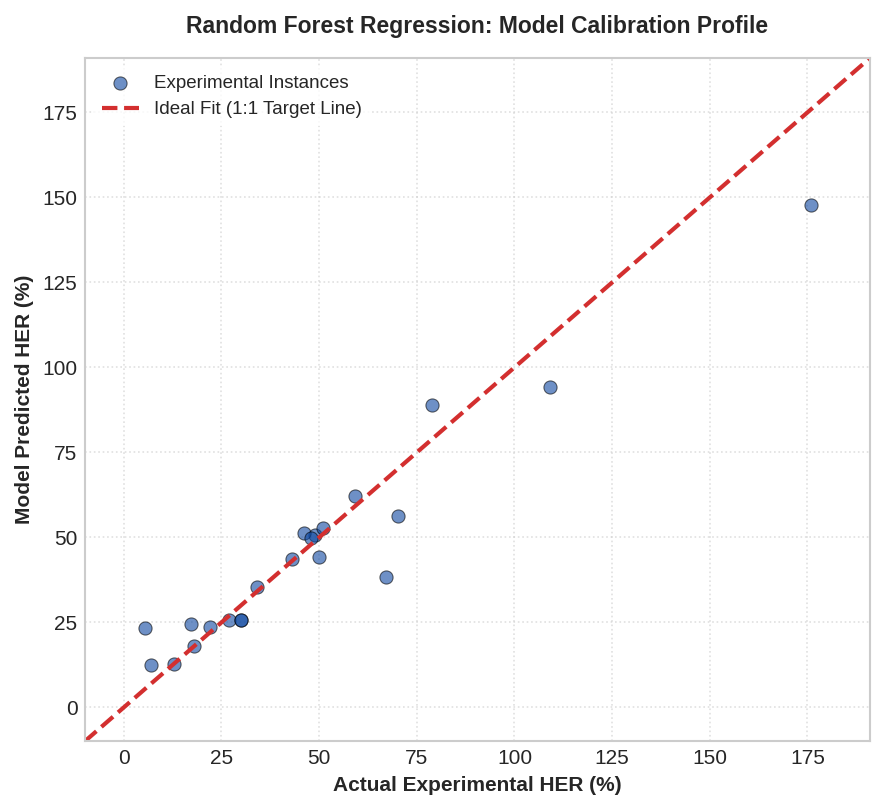

In [8]:
plt.figure(figsize=(6, 5.5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Plot the evaluation point array
plt.scatter(y_test, y_pred, color='#0D47A1', alpha=0.6, edgecolors='black', linewidths=0.5, s=40, label='Experimental Instances')

# Compute the exact bounding limits for the diagonal 1:1 parity line
max_bound = max(int(max(y_test)), int(max(y_pred))) + 15
min_bound = min(int(min(y_test)), int(min(y_pred))) - 15
plt.plot([min_bound, max_bound], [min_bound, max_bound], linestyle='--', color='#D32F2F', lw=2, label='Ideal Fit (1:1 Target Line)')

# Apply clear typography and engineering labels
plt.title('Random Forest Regression: Model Calibration Profile', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Actual Experimental HER (%)', fontsize=10, fontweight='bold')
plt.ylabel('Model Predicted HER (%)', fontsize=10, fontweight='bold')

plt.xlim(min_bound, max_bound)
plt.ylim(min_bound, max_bound)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=9)

plt.tight_layout()
plt.show()